<a href="https://www.kaggle.com/code/sonawanelalitsunil/forbes-global-2000-2025-ml-29-92?scriptVersionId=256075372" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/forbes-the-global-2000-companies-2025/Forbes_2000_Companies_2025.csv


## Title: Forbes Global 2000: World’s Largest Public Companies 2025

## Description:
The Forbes Global 2000 list for 2025 ranks the world’s largest publicly traded companies based on a composite score of revenues, profits, assets, and market value. It features corporate giants from diverse industries, including technology, finance, energy, healthcare, and manufacturing. This year’s list highlights the shifting global economic landscape, showcasing the dominance of multinational conglomerates, the rise of emerging market leaders, and the continued strength of tech innovators. The ranking serves as a benchmark for corporate scale, financial power, and global influence, offering valuable insights for investors, analysts, and business leaders.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/forbes-the-global-2000-companies-2025/Forbes_2000_Companies_2025.csv", sep=None, engine="python")


In [3]:
df.head()

,Rank,Company,Headquarters,Industry,Sales ($B),Profit ($B),Assets ($B),Market Value ($B)
0,1,JPMorganChase,United States,Banking,285.11,59.36,"4,357.86",677.8
1,2,Berkshire Hathaway,United States,Insurance,371.43,89,"1,153.88","1,145.46"
2,3,ICBC,China,Banking,221.96,50.84,"6,688.6",251.33
3,4,Saudi Arabian Oil Company (Saudi Aramco),Saudi Arabia,Oil & Gas Operations,480.15,104.97,645.03,"1,663.38"
4,5,Amazon,United States,Retail and Wholesale,637.96,59.25,624.89,"2,005.64"


In [4]:
df.tail()

,Rank,Company,Headquarters,Industry,Sales ($B),Profit ($B),Assets ($B),Market Value ($B)
1995,1996,Dino Polska,Poland,Food Markets,7.360,0.3781,3.16,13.84
1996,1997,China Aviation Oil,Singapore,Trading Companies,15.520,0.0784,1.99,0.559
1997,1998,Jet2,United Kingdom,Business Services & Supplies,8.790,0.6288,7.95,3.93
1998,1998,Keiyo Bank,Japan,Banking,0.474,0.0927,42.56,0.679
1999,1998,PT Lippo Karawaci,Indonesia,Construction,0.716,1.18,3.34,0.366


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rank               2000 non-null   int64  
 1   Company            2000 non-null   object 
 2   Headquarters       2000 non-null   object 
 3   Industry           2000 non-null   object 
 4   Sales ($B)         2000 non-null   float64
 5   Profit ($B)        2000 non-null   object 
 6   Assets ($B)        2000 non-null   object 
 7   Market Value ($B)  2000 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 125.1+ KB


In [6]:
df.describe()

,Rank,Sales ($B)
count,2000.000000,2000.000000
mean,1000.331000,26.441630
std,577.430053,47.928105
min,1.000000,-21.470000
25%,500.750000,6.147500
50%,1000.500000,12.950000
75%,1500.250000,25.707500
max,1998.000000,680.990000


In [7]:
df.isnull().sum()

Rank                 0
Company              0
Headquarters         0
Industry             0
Sales ($B)           0
Profit ($B)          0
Assets ($B)          0
Market Value ($B)    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Rank                   int64
Company               object
Headquarters          object
Industry              object
Sales ($B)           float64
Profit ($B)           object
Assets ($B)           object
Market Value ($B)     object
dtype: object

In [10]:
df.shape

(2000, 8)

In [11]:
df.columns

Index(['Rank', 'Company', 'Headquarters', 'Industry', 'Sales ($B)',
       'Profit ($B)', 'Assets ($B)', 'Market Value ($B)'],
      dtype='object')

## Data visualizations

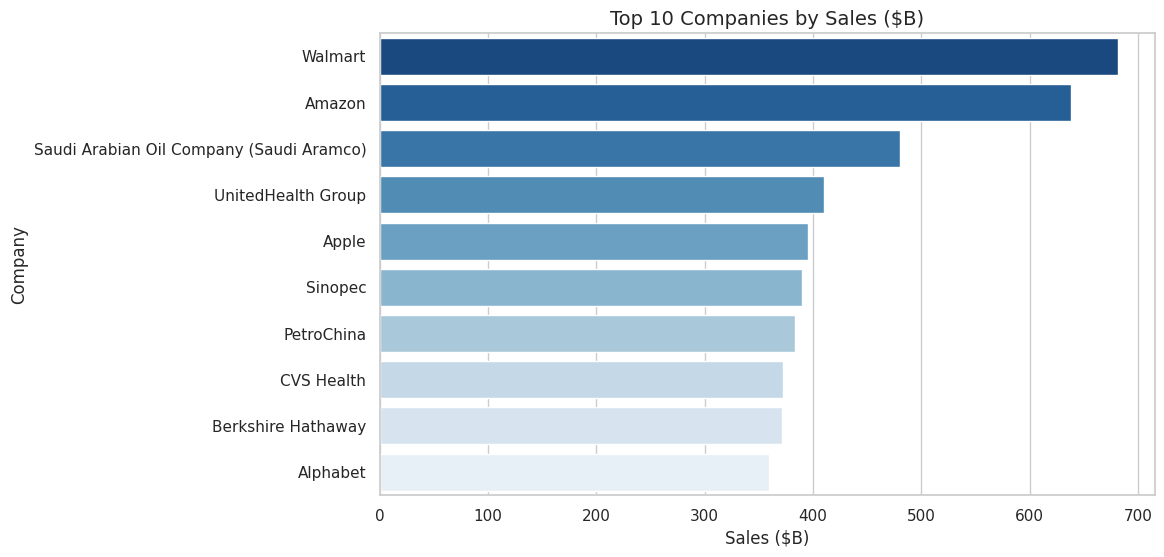

In [12]:
# Ensure correct numeric types (remove $ and B if present)
for col in ['Sales ($B)', 'Profit ($B)', 'Assets ($B)', 'Market Value ($B)']:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace('$', '').str.replace('B', ''), errors='coerce')

# Set style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# 1️⃣ Top 10 Companies by Sales
top_sales = df.nlargest(10, 'Sales ($B)')
sns.barplot(data=top_sales, x='Sales ($B)', y='Company', palette="Blues_r")
plt.title("Top 10 Companies by Sales ($B)", fontsize=14)
plt.xlabel("Sales ($B)")
plt.ylabel("Company")
plt.show()


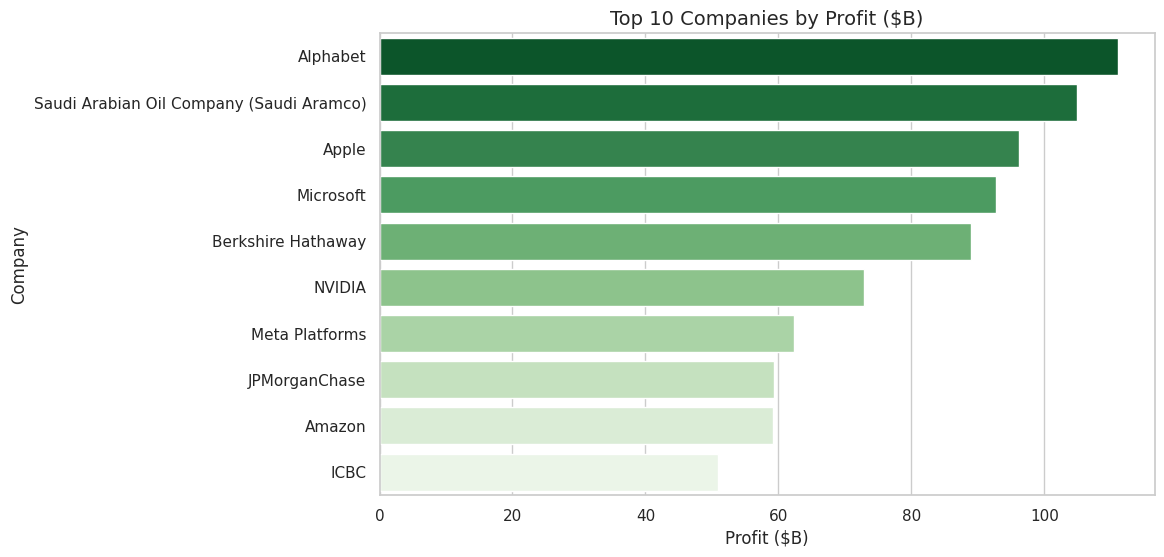

In [13]:
top_profit = df.nlargest(10, 'Profit ($B)')
sns.barplot(data=top_profit, x='Profit ($B)', y='Company', palette="Greens_r")
plt.title("Top 10 Companies by Profit ($B)", fontsize=14)
plt.xlabel("Profit ($B)")
plt.ylabel("Company")
plt.show()

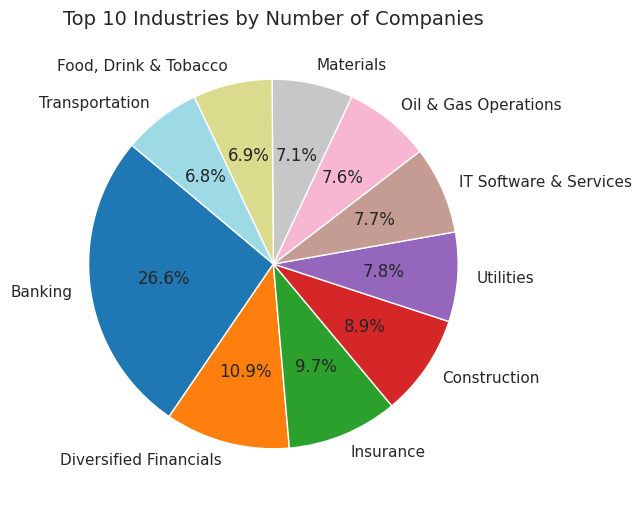

In [14]:
industry_counts = df['Industry'].value_counts().head(10)
industry_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140, cmap='tab20')
plt.title("Top 10 Industries by Number of Companies", fontsize=14)
plt.ylabel("")
plt.show()

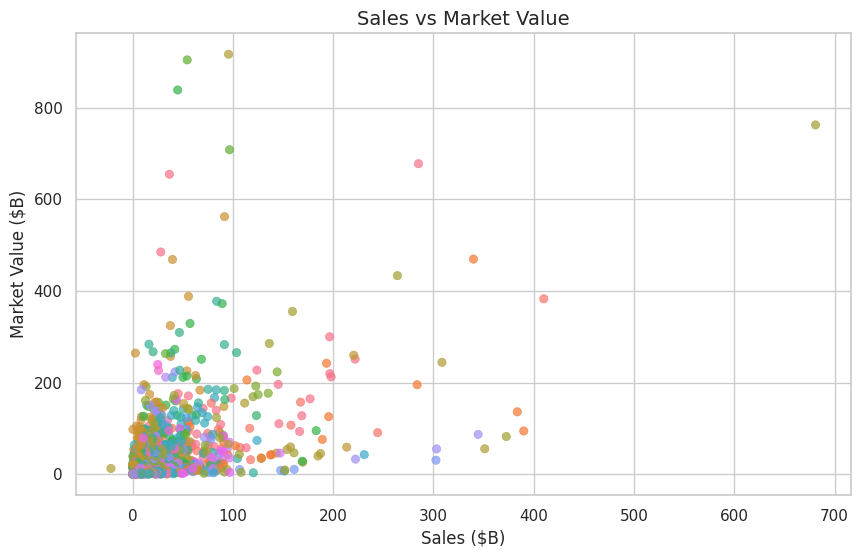

In [15]:
sns.scatterplot(data=df, x='Sales ($B)', y='Market Value ($B)', hue='Industry', alpha=0.7, edgecolor=None, legend=False)
plt.title("Sales vs Market Value", fontsize=14)
plt.xlabel("Sales ($B)")
plt.ylabel("Market Value ($B)")
plt.show()


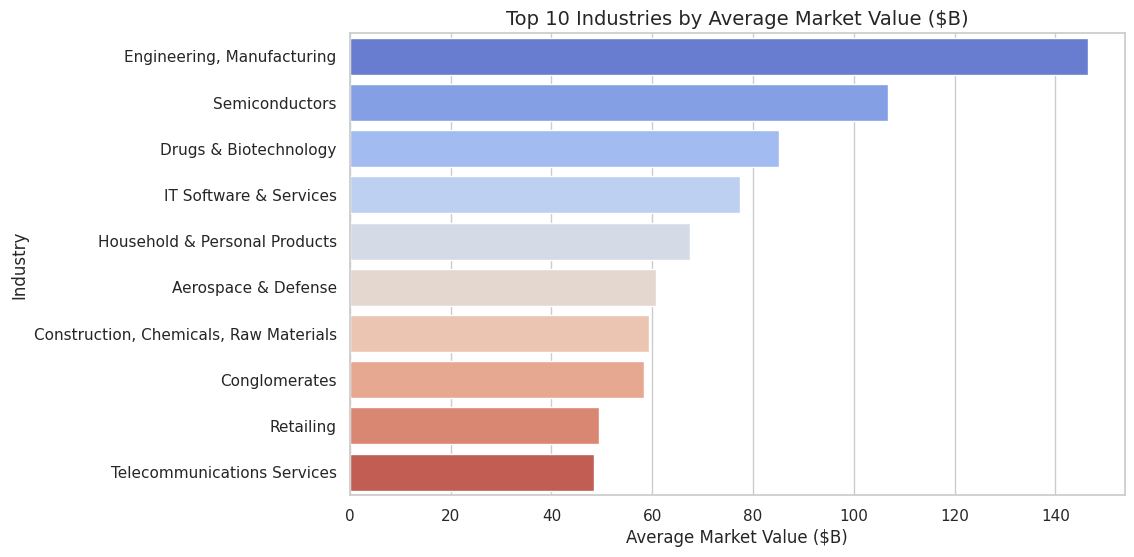

In [16]:
industry_mv = df.groupby('Industry')['Market Value ($B)'].mean().nlargest(10)
sns.barplot(x=industry_mv.values, y=industry_mv.index, palette="coolwarm")
plt.title("Top 10 Industries by Average Market Value ($B)", fontsize=14)
plt.xlabel("Average Market Value ($B)")
plt.ylabel("Industry")
plt.show()

## Predictive modeling

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [18]:
# Clean numeric columns
for col in ['Sales ($B)', 'Profit ($B)', 'Assets ($B)', 'Market Value ($B)']:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace('$', '').str.replace('B', ''), errors='coerce')

# Drop rows with missing values
df.dropna(inplace=True)

# Label encode categorical features
le = LabelEncoder()
for col in ['Company', 'Headquarters', 'Industry']:
    df[col] = le.fit_transform(df[col])

# Define features (X) and target (y)
X = df.drop(columns=['Industry'])  # features
y = df['Industry']  # target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

# Train and evaluate models
accuracies = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies[name] = round(accuracy_score(y_test, y_pred) * 100, 2)

# Show accuracies
for model, acc in accuracies.items():
    print(f"{model}: {acc}% Accuracy")

Logistic Regression: 23.02% Accuracy
Decision Tree: 21.99% Accuracy
Random Forest: 29.92% Accuracy
Naive Bayes: 12.53% Accuracy
SVM: 15.35% Accuracy
KNN: 13.55% Accuracy


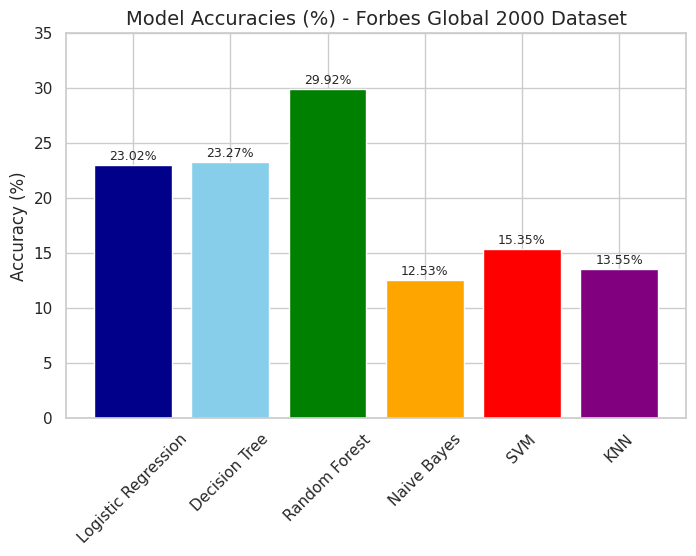

In [20]:
accuracies = {
    "Logistic Regression": 23.02,
    "Decision Tree": 23.27,
    "Random Forest": 29.92,
    "Naive Bayes": 12.53,
    "SVM": 15.35,
    "KNN": 13.55
}

# Plot
plt.figure(figsize=(8,5))
plt.bar(accuracies.keys(), accuracies.values(), color=['darkblue', 'skyblue', 'green', 'orange', 'red', 'purple'])
plt.title("Model Accuracies (%) - Forbes Global 2000 Dataset", fontsize=14)
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45)
plt.ylim(0, 35)

# Annotate values
for i, acc in enumerate(accuracies.values()):
    plt.text(i, acc + 0.5, f"{acc}%", ha='center', fontsize=9)

plt.show()

## Thank you..pls upvote!!!